In [7]:
import glob
import json
import os
from pathlib import Path

import h5py
import numpy as np
import scipy.io as io
import scipy.spatial
from matplotlib import cm as CM
from matplotlib import pyplot as plt
from PIL import Image
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

%matplotlib inline

In [8]:
# Adapted from https://github.com/davideverona/deep-crowd-counting_crowdnet
def gaussian_filter_density(gt: np.ndarray) -> np.ndarray:
    """Build a per-head adaptive density map from a 0/1 head map."""
    print(gt.shape)
    density = np.zeros(gt.shape, dtype=np.float32)
    gt_count = int(np.count_nonzero(gt))
    if gt_count == 0:
        return density

    # Stack non-zero coordinates as (x, y) pairs.
    nz = np.nonzero(gt)
    pts = np.column_stack((nz[1], nz[0]))

    leafsize = 2048
    tree = scipy.spatial.cKDTree(pts.copy(), leafsize=leafsize)
    distances, _ = tree.query(pts, k=4)

    print("generate density...")
    for i, pt in enumerate(pts):
        pt2d = np.zeros(gt.shape, dtype=np.float32)
        pt2d[pt[1], pt[0]] = 1.0
        if gt_count > 1:
            sigma = (distances[i][1] + distances[i][2] + distances[i][3]) * 0.1
        else:
            sigma = float(np.average(np.array(gt.shape))) / 2.0 / 2.0  # case: 1 point
        density += gaussian_filter(pt2d, sigma, mode="constant")
    print("done.")
    return density

In [ ]:
root = Path("./data/ShanghaiTech")

In [ ]:
MAX_TRAIN = 20
MAX_TEST = 10

part_A_train = root / "part_A_final" / "train_data" / "images"
part_A_test = root / "part_A_final" / "test_data" / "images"
part_B_train = root / "part_B_final" / "train_data" / "images"
part_B_test = root / "part_B_final" / "test_data" / "images"

path_sets = [(part_A_train, MAX_TRAIN), (part_A_test, MAX_TEST)]


In [10]:
img_paths: list[str] = []
for path, limit in path_sets:
    folder_paths = sorted(str(p) for p in Path(path).glob("*.jpg"))
    if limit is not None:
        folder_paths = folder_paths[:limit]
    img_paths.extend(folder_paths)

print(f"Selected {len(img_paths)} images")


Selected 30 images


In [11]:
for img_path in tqdm(img_paths, desc="part_A density maps"):
    print(img_path)
    mat_path = (
        img_path.replace(".jpg", ".mat")
        .replace("images", "ground_truth")
        .replace("IMG_", "GT_IMG_")
    )
    mat = io.loadmat(mat_path)
    img = plt.imread(img_path)
    k = np.zeros((img.shape[0], img.shape[1]))
    gt = mat["image_info"][0, 0][0, 0][0]
    for i in range(len(gt)):
        if int(gt[i][1]) < img.shape[0] and int(gt[i][0]) < img.shape[1]:
            k[int(gt[i][1]), int(gt[i][0])] = 1
    k = gaussian_filter_density(k)
    out_path = img_path.replace(".jpg", ".h5").replace("images", "ground_truth")
    with h5py.File(out_path, "w") as hf:
        hf["density"] = k

part_A density maps:   0%|          | 0/30 [00:00<?, ?it/s]

data\ShanghaiTech\part_A_final\train_data\images\IMG_1.jpg
(768, 1024)
generate density...


part_A density maps:   3%|▎         | 1/30 [00:27<13:22, 27.68s/it]

done.
data\ShanghaiTech\part_A_final\train_data\images\IMG_10.jpg
(683, 1024)
generate density...


part_A density maps:   7%|▋         | 2/30 [00:53<12:29, 26.77s/it]

...

done.
data\ShanghaiTech\part_A_final\test_data\images\IMG_106.jpg
(476, 1001)
generate density...


part_A density maps:  97%|█████████▋| 29/30 [05:58<00:14, 14.86s/it]

done.
data\ShanghaiTech\part_A_final\test_data\images\IMG_107.jpg
(463, 691)
generate density...


part_A density maps: 100%|██████████| 30/30 [06:00<00:00, 12.02s/it]

done.


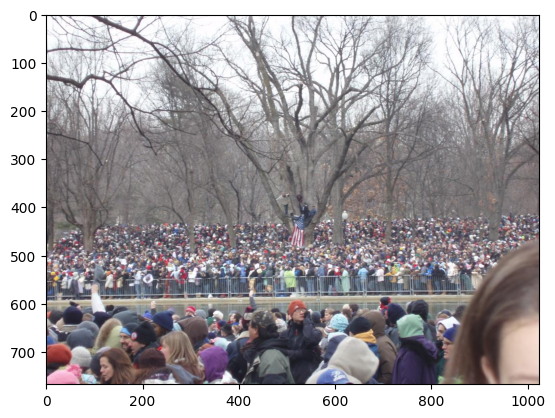

In [12]:
plt.imshow(Image.open(img_paths[0]))

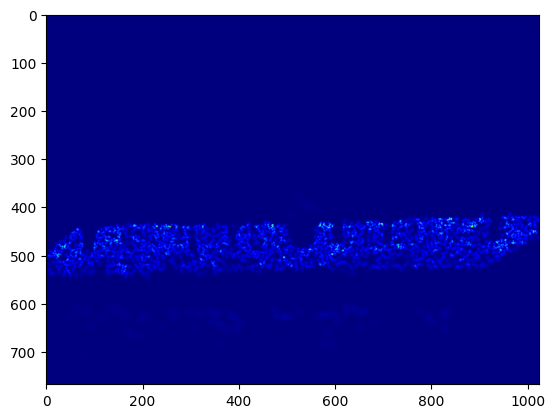

In [13]:
gt_h5_path = img_paths[0].replace(".jpg", ".h5").replace("images", "ground_truth")
with h5py.File(gt_h5_path, "r") as gt_file:
    groundtruth = np.asarray(gt_file["density"])
plt.imshow(groundtruth, cmap=CM.jet)

In [14]:
np.sum(groundtruth) 

np.float32(1543.8407)

In [15]:
path_sets = [(part_B_train, MAX_TRAIN), (part_B_test, MAX_TEST)]


In [16]:
img_paths = []
for path, limit in path_sets:
    folder_paths = sorted(str(p) for p in Path(path).glob("*.jpg"))
    if limit is not None:
        folder_paths = folder_paths[:limit]
    img_paths.extend(folder_paths)

print(f"Selected {len(img_paths)} images")


Selected 30 images


In [17]:
for img_path in tqdm(img_paths, desc="part_B density maps"):
    print(img_path)
    mat_path = (
        img_path.replace(".jpg", ".mat")
        .replace("images", "ground_truth")
        .replace("IMG_", "GT_IMG_")
    )
    mat = io.loadmat(mat_path)
    img = plt.imread(img_path)
    k = np.zeros((img.shape[0], img.shape[1]))
    gt = mat["image_info"][0, 0][0, 0][0]
    for i in range(len(gt)):
        if int(gt[i][1]) < img.shape[0] and int(gt[i][0]) < img.shape[1]:
            k[int(gt[i][1]), int(gt[i][0])] = 1
    k = gaussian_filter(k, 15)
    out_path = img_path.replace(".jpg", ".h5").replace("images", "ground_truth")
    with h5py.File(out_path, "w") as hf:
        hf["density"] = k

part_B density maps:   3%|▎         | 1/30 [00:00<00:03,  9.33it/s]

data\ShanghaiTech\part_B_final\train_data\images\IMG_1.jpg
data\ShanghaiTech\part_B_final\train_data\images\IMG_10.jpg


part_B density maps:  10%|█         | 3/30 [00:00<00:03,  8.49it/s]

data\ShanghaiTech\part_B_final\train_data\images\IMG_100.jpg
data\ShanghaiTech\part_B_final\train_data\images\IMG_101.jpg


part_B density maps:  17%|█▋        | 5/30 [00:00<00:02,  8.60it/s]

...

part_B density maps:  90%|█████████ | 27/30 [00:03<00:00,  6.77it/s]

data\ShanghaiTech\part_B_final\test_data\images\IMG_104.jpg
data\ShanghaiTech\part_B_final\test_data\images\IMG_105.jpg


part_B density maps:  97%|█████████▋| 29/30 [00:03<00:00,  6.98it/s]

data\ShanghaiTech\part_B_final\test_data\images\IMG_106.jpg
data\ShanghaiTech\part_B_final\test_data\images\IMG_107.jpg


part_B density maps: 100%|██████████| 30/30 [00:03<00:00,  7.88it/s]


In [ ]:
def collect(folder: Path, limit: int | None) -> list[str]:
    paths = sorted(str(p) for p in Path(folder).glob("*.jpg"))
    if limit is not None:
        paths = paths[:limit]
    return paths


splits = {
    "part_A_train.json": collect(part_A_train, MAX_TRAIN),
    "part_A_val.json":   collect(part_A_test,  MAX_TEST),
    "part_A_test.json":  collect(part_A_test,  MAX_TEST),
    "part_B_train.json": collect(part_B_train, MAX_TRAIN),
    "part_B_val.json":   collect(part_B_test,  MAX_TEST),
    "part_B_test.json":  collect(part_B_test,  MAX_TEST),
}

for name, items in splits.items():
    Path(name).write_text(json.dumps(items, indent=2))
    print(f"wrote {name:24s} ({len(items)} images)")
